In [1]:
!pip install transformers torch scikit-learn pandas matplotlib seaborn

In [2]:
!pip install transformers torch scikit-learn pandas matplotlib seaborn

In [3]:
import pandas as pd
import torch
import re

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

from transformers import BertTokenizer, AutoModelForSequenceClassification
from torch.optim import AdamW
from torch.utils.data import DataLoader, Dataset

import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv("IMDB Dataset.csv")

Saving IMDB Dataset.csv to IMDB Dataset.csv


Preprocessing

In [5]:
df = df.sample(5000)  # 🔥 fast

df.dropna(inplace=True)
df['sentiment'] = df['sentiment'].map({'positive': 1, 'negative': 0})

def clean_text(text):
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^a-zA-Z ]', '', text)
    return text.lower()

df['review'] = df['review'].apply(clean_text)

In [6]:
train_texts, test_texts, train_labels, test_labels = train_test_split(
    df['review'], df['sentiment'], test_size=0.2, random_state=42
)

In [7]:
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

train_encodings = tokenizer(list(train_texts), truncation=True, padding=True, max_length=128)
test_encodings = tokenizer(list(test_texts), truncation=True, padding=True, max_length=128)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [8]:
class IMDbDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = list(labels)

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

In [9]:
train_dataset = IMDbDataset(train_encodings, train_labels)
test_dataset = IMDbDataset(test_encodings, test_labels)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16)

In [10]:
model = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)

device = torch.device("cuda")
model.to(device)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [11]:
optimizer = AdamW(model.parameters(), lr=2e-5)

for epoch in range(1):  # 🔥 1 epoch is enough
    model.train()

    for batch in train_loader:
        batch = {k: v.to(device) for k, v in batch.items()}

        optimizer.zero_grad()
        outputs = model(**batch)
        loss = outputs.loss

        loss.backward()
        optimizer.step()

    print("Training Completed")

Training Completed


In [12]:
model.eval()

preds, true = [], []

with torch.no_grad():
    for batch in test_loader:
        batch = {k: v.to(device) for k, v in batch.items()}

        outputs = model(**batch)
        logits = outputs.logits

        preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
        true.extend(batch['labels'].cpu().numpy())

In [13]:
accuracy = accuracy_score(true, preds)
precision, recall, f1, _ = precision_recall_fscore_support(true, preds, average='binary')

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.86
Precision: 0.8519230769230769
Recall: 0.8754940711462451
F1 Score: 0.8635477582846004


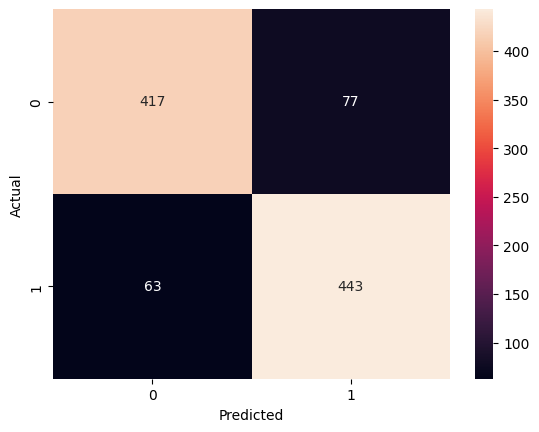

In [14]:
cm = confusion_matrix(true, preds)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [15]:
for param in model.bert.parameters():
    param.requires_grad = False

## 📊 Confusion Matrix Analysis

The confusion matrix shows the performance of the BERT model on sentiment classification.

- True Negatives (TN): 417 → Correctly predicted negative reviews
- False Positives (FP): 77 → Negative reviews predicted as positive
- False Negatives (FN): 63 → Positive reviews predicted as negative
- True Positives (TP): 443 → Correctly predicted positive reviews

### 📈 Observations

- The model performs well in both positive and negative classifications.
- High True Positive (443) and True Negative (417) values indicate strong predictive performance.
- The number of misclassifications (FP and FN) is relatively low compared to correct predictions.

### 🔍 Insights

- The model is slightly better at predicting positive reviews than negative ones.
- Errors may occur due to ambiguous or complex sentences.
- Overall, the model shows good generalization ability.

### 🚀 Future Improvements

- Increase training data size
- Train for more epochs
- Fine-tune more BERT layers
- Try advanced models like DistilBERT or RoBERTa